In [1]:
import pandas as pd
import numpy as np
from sklearn.covariance import MinCovDet
import matplotlib.pyplot as plt

### Load the dataset

In [2]:
df=pd.read_csv('data.csv')
df['Diabetes_binary']=df['Diabetes_binary'].astype(int)
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


### Data Cleaning

In [3]:
# 1. Removing Duplicates
df = df.drop_duplicates()
print(f"Data shape after removing duplicates: {df.shape}")

# 2. Handling Missing Values
# Check for missing values
missing_summary = df.isnull().sum()
print("Missing values in each column:\n", missing_summary)

# 3. Detecting Outliers for non-binary cols
# Use the MCD 
cols = ['BMI','GenHlth','MentHlth','PhysHlth','Age','Education','Income']
mcd = MinCovDet().fit(df[cols])
mahalanobis_distances = mcd.mahalanobis(df[cols])
threshold = np.percentile(mahalanobis_distances, 95)
df_t=df.copy()
df_t['Outlier'] = mahalanobis_distances > threshold
print(f"Number of outliers detected: {df_t['Outlier'].sum()}")
df_clean = df_t[df_t['Outlier'] == False].drop(columns=['Outlier'])
print(f"Data shape after removing outliers: {df_clean.shape}")

Data shape after removing duplicates: (229474, 22)
Missing values in each column:
 Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
Number of outliers detected: 11474
Data shape after removing outliers: (218000, 22)


### Histogram function

In [4]:
def hist_numeric(df,cols):
    features = cols

    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        df[df['Diabetes_binary'] == 0][feature].plot.hist(
            bins=20, alpha=0.5, label='Diabetes=0', ax=axes[i], color='green'
        )
        df[df['Diabetes_binary'] == 1][feature].plot.hist(
            bins=20, alpha=0.8, label='Diabetes=1', ax=axes[i], color='orange'
        )
        axes[i].set_title(feature)
        axes[i].legend()
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    
def pie_binary(df, cols):
    features = cols
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features * 2 + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        data_0 = df[df['Diabetes_binary'] == 0][feature].value_counts()
        data_1 = df[df['Diabetes_binary'] == 1][feature].value_counts()
        
        axes[2 * i].pie(data_0, labels=[int(label) for label in data_0.index], autopct='%1.1f%%', colors=['cyan', 'pink'], startangle=90)
        axes[2 * i].set_title(f'{feature} Distribution when Diabetes_binary=0')

        axes[2 * i + 1].pie(data_1, labels=[int(label) for label in data_1.index], autopct='%1.1f%%', colors=['blue', 'red'], startangle=90)
        axes[2 * i + 1].set_title(f'{feature} Distribution when Diabetes_binary=1')


    plt.tight_layout()
    plt.show()

### Original data EDA

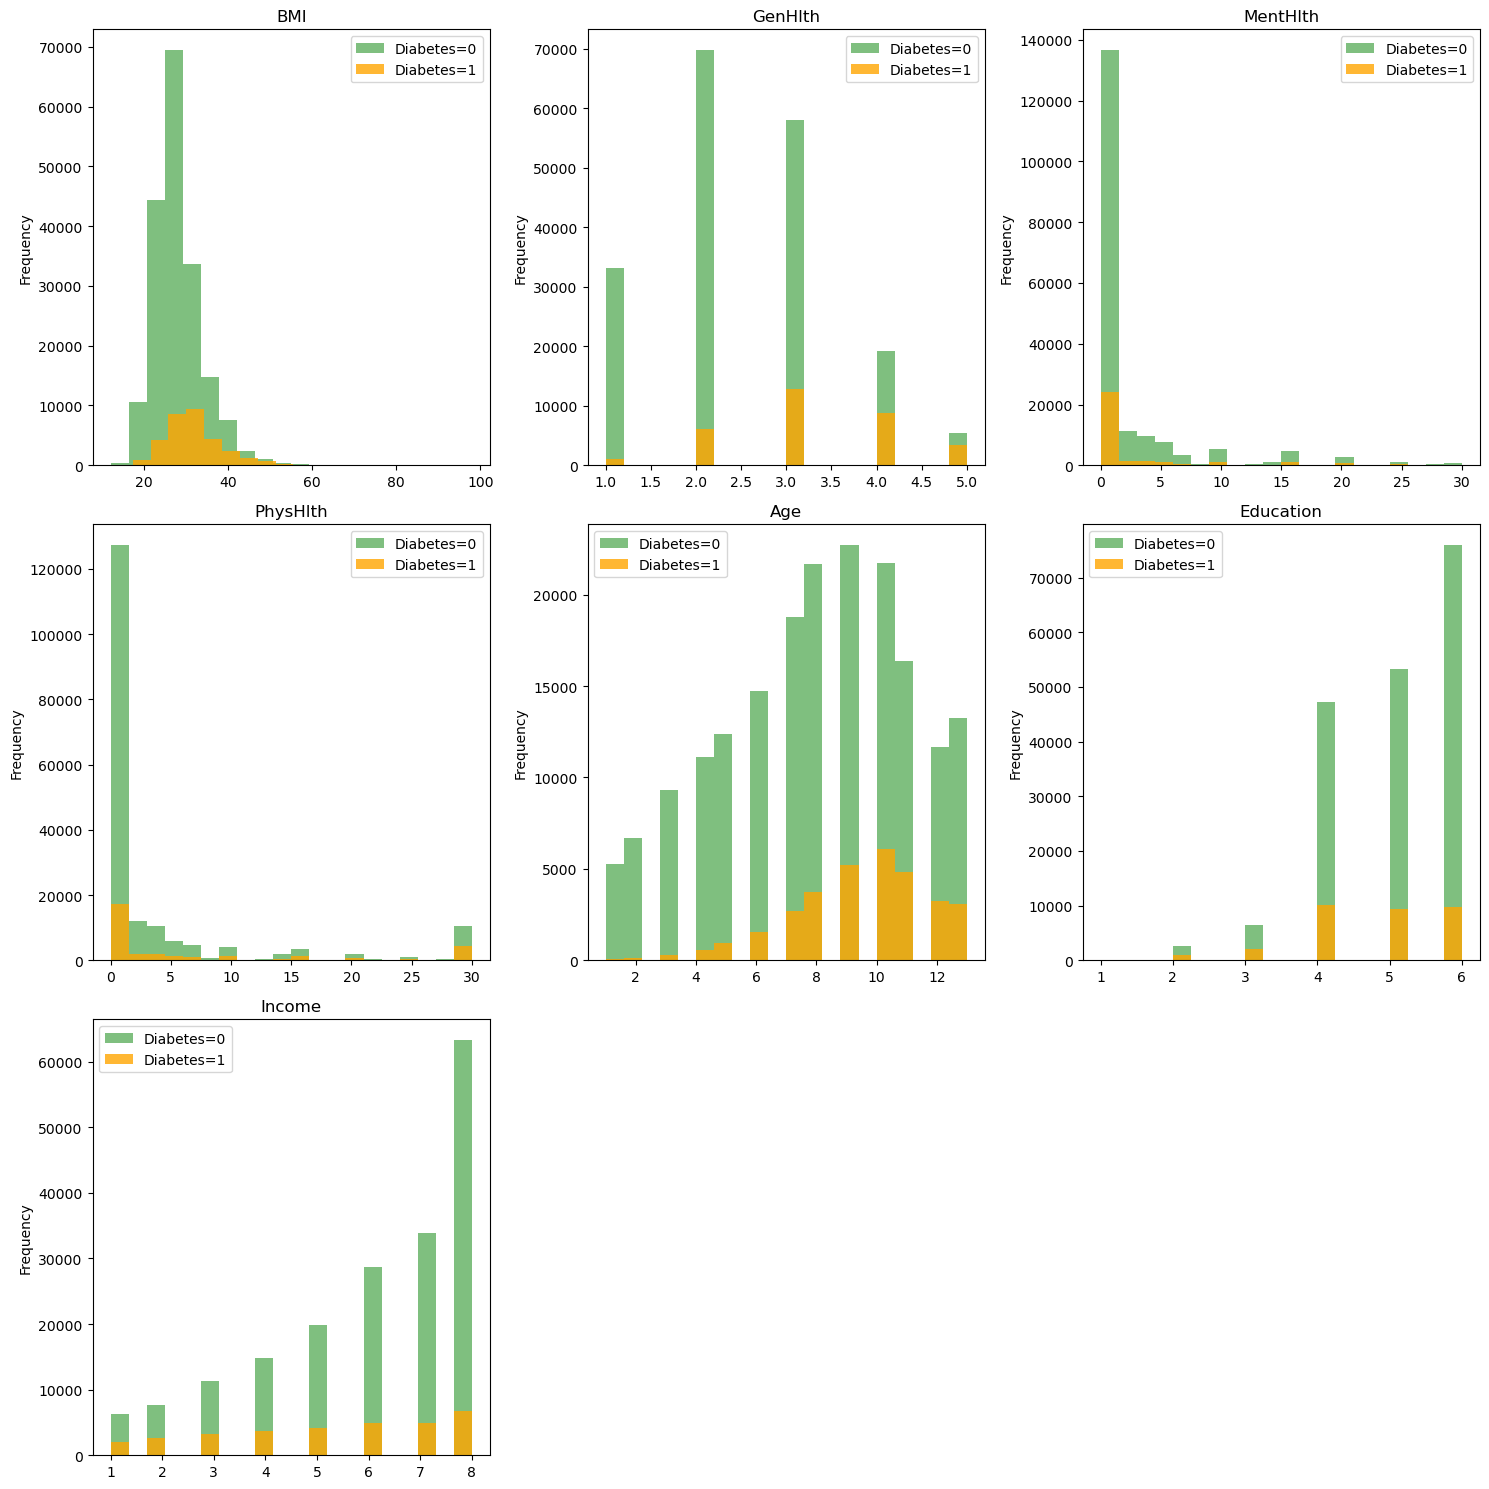

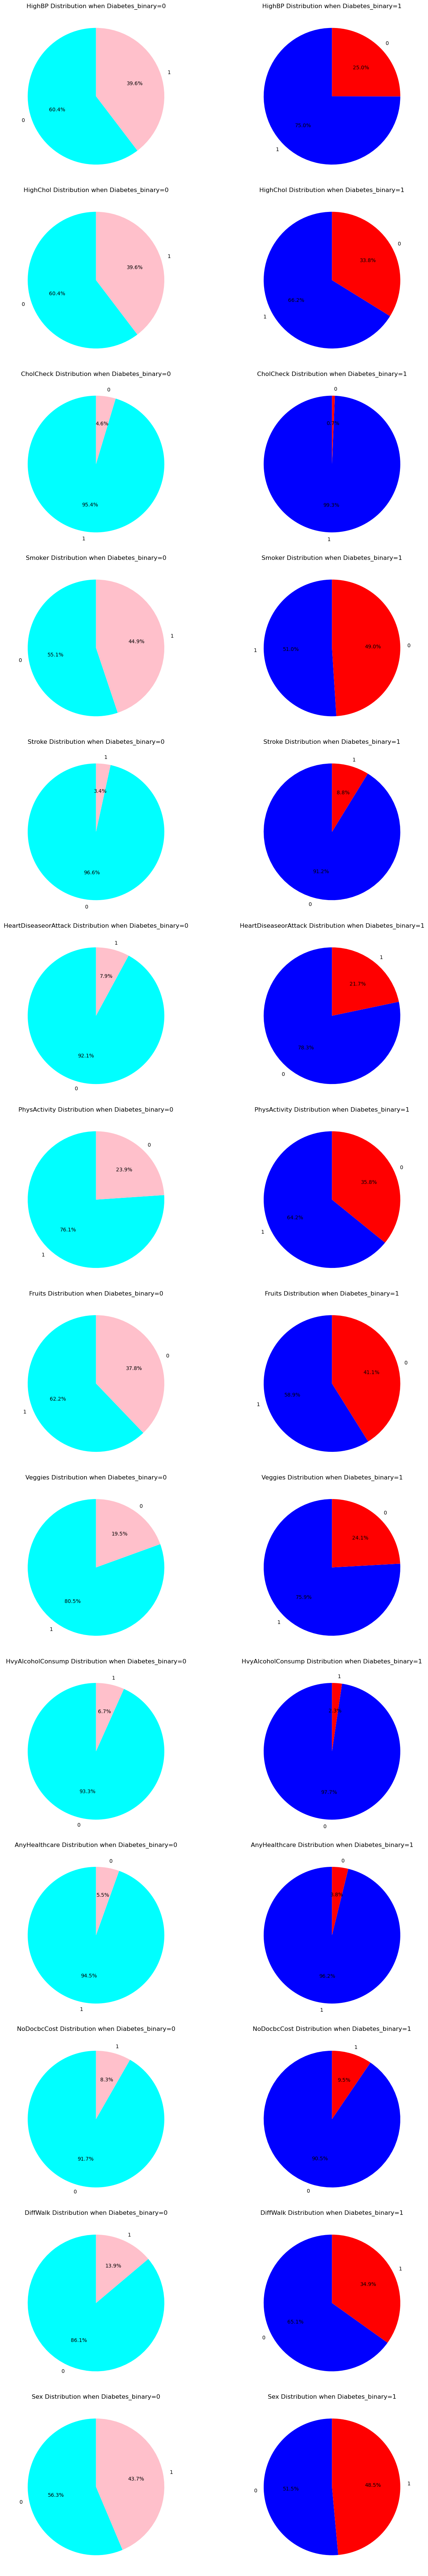

In [6]:
hist_numeric(df_clean,['BMI','GenHlth','MentHlth','PhysHlth','Age','Education','Income'])
pie_binary(df_clean,['HighBP', 'HighChol', 'CholCheck', 'Smoker','Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies','HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'])

### Balance the data

In [5]:
from imblearn.over_sampling import SMOTE, ADASYN
from scipy.stats import pearsonr
import seaborn as sns

X = df_clean.drop(columns=['Diabetes_binary'])
y = df_clean['Diabetes_binary']

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("SMOTE class distribution:", y_smote.value_counts())

SMOTE class distribution: Diabetes_binary
0    186735
1    186735
Name: count, dtype: int64


### P-value & Correlations

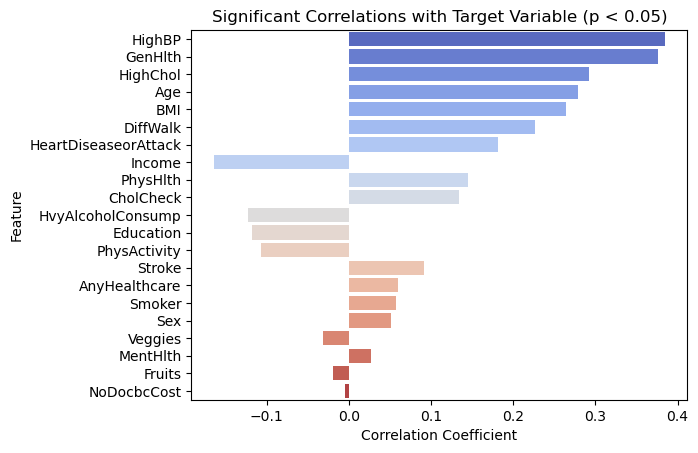

                 Feature  Correlation        P-value  Abs_Correlation
0                 HighBP     0.384495   0.000000e+00         0.384495
1               HighChol     0.292318   0.000000e+00         0.292318
2              CholCheck     0.133549   0.000000e+00         0.133549
3                    BMI     0.263778   0.000000e+00         0.263778
4                 Smoker     0.058025  6.942923e-276         0.058025
5                 Stroke     0.090982   0.000000e+00         0.090982
6   HeartDiseaseorAttack     0.181686   0.000000e+00         0.181686
7           PhysActivity    -0.106795   0.000000e+00         0.106795
8                 Fruits    -0.019311   3.799436e-32         0.019311
9                Veggies    -0.031539   8.107637e-83         0.031539
10     HvyAlcoholConsump    -0.122552   0.000000e+00         0.122552
11         AnyHealthcare     0.060276  1.426926e-297         0.060276
12           NoDocbcCost    -0.003939   1.608780e-02         0.003939
13               Gen

In [6]:
from scipy.stats import pointbiserialr,chi2_contingency
import seaborn as sns

def calculate_and_visualize_correlations(X_smote, y_smote):
    # Initialize lists to store correlation coefficients and p-values
    correlations = []
    p_values = []

    # Calculate correlation and p-value for each feature
    for col in X_smote.columns:
        if X_smote[col].nunique() == 2:  # Binary feature
            # Chi-square test for Binary feature vs. Binary target
            contingency_table = pd.crosstab(X_smote[col], y_smote)
            chi2, p, _, _ = chi2_contingency(contingency_table)
            correlations.append(chi2)
            p_values.append(p)
        else:
            # Point-Biserial correlation for Continuous feature vs. Binary target
            corr, p = pointbiserialr(X_smote[col], y_smote)
            correlations.append(corr)
            p_values.append(p)

    # Create a DataFrame to store results
    results = pd.DataFrame({
        "Feature": X_smote.columns,
        "Correlation": correlations,
        "P-value": p_values
    })

    # Filter and sort results where p-value < 0.05
    results['Abs_Correlation'] = results['Correlation'].abs()
    significant_results = results[results['P-value'] < 0.05].sort_values(by='Abs_Correlation', ascending=False)

    # Plot significant correlations
    sns.barplot(data=significant_results, x='Correlation', y='Feature', palette='coolwarm')
    plt.title('Significant Correlations with Target Variable (p < 0.05)')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Feature')
    plt.show()
    print(results)

    return results

results = calculate_and_visualize_correlations(X_smote, y_smote)

### Logistic Regression

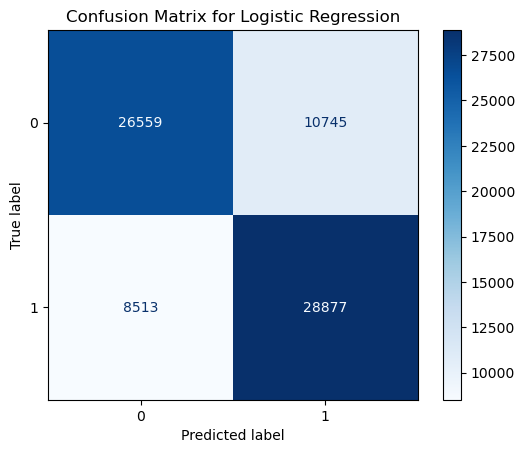

Accuracy of Logistic Regression: 0.7422


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_smote_scaled = scaler.fit_transform(X_smote)

X_train, X_test, y_train, y_test = train_test_split(X_smote_scaled, y_smote, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of Logistic Regression: {accuracy:.4f}')

### Logistic Regression + PCA (95%)

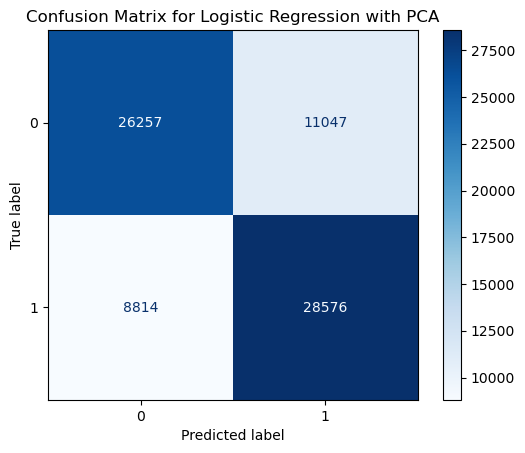

Accuracy of Logistic Regression + PCA: 0.7341


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=0.95)  # Retain 95% of the variance
X_smote_pca = pca.fit_transform(X_smote_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_smote_pca, y_smote, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression with PCA')
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of Logistic Regression + PCA: {accuracy:.4f}')

In [10]:
print('Logistic Regreesion assumes linear relationship between features and target variable.')
print('But in the dataset, there are both bineray data and non-binary data, which cannot have linear relationship.')
print('The use of PCA will lead to some important features not being captured.')

Logistic Regreesion assumes linear relationship between features and target variable.
But in the dataset, there are both bineray data and non-binary data, which cannot have linear relationship.
The use of PCA will lead to some important features not being captured.


### XG Boost

Accuracy: 0.914799046777519


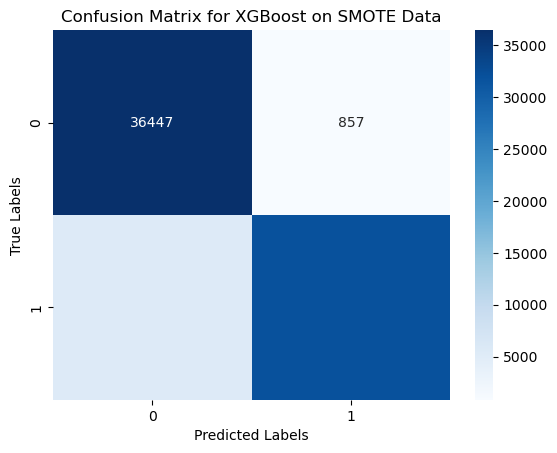

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92     37304
           1       0.97      0.85      0.91     37390

    accuracy                           0.91     74694
   macro avg       0.92      0.91      0.91     74694
weighted avg       0.92      0.91      0.91     74694



,Feature,Importance Score
0,HighBP,0.282836
1,HighChol,0.105012
2,GenHlth,0.069185
3,Smoker,0.059791
4,Sex,0.056320
5,Fruits,0.055144
6,HeartDiseaseorAttack,0.050618
7,Veggies,0.043878
8,CholCheck,0.042041
9,PhysActivity,0.041258


In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


scaler = StandardScaler()
X_smote_scaled = scaler.fit_transform(X_smote)

X_train, X_test, y_train, y_test = train_test_split(X_smote_scaled, y_smote, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(eval_metric='logloss', alpha=1)
xgb_model.fit(X_train, y_train)


y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix for XGBoost on SMOTE Data")
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

importance_scores = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_smote.columns, 
    'Importance Score': importance_scores
})

feature_importance_df = feature_importance_df.sort_values(by='Importance Score', ascending=False).reset_index(drop=True)
feature_importance_df

### K-means cluster number

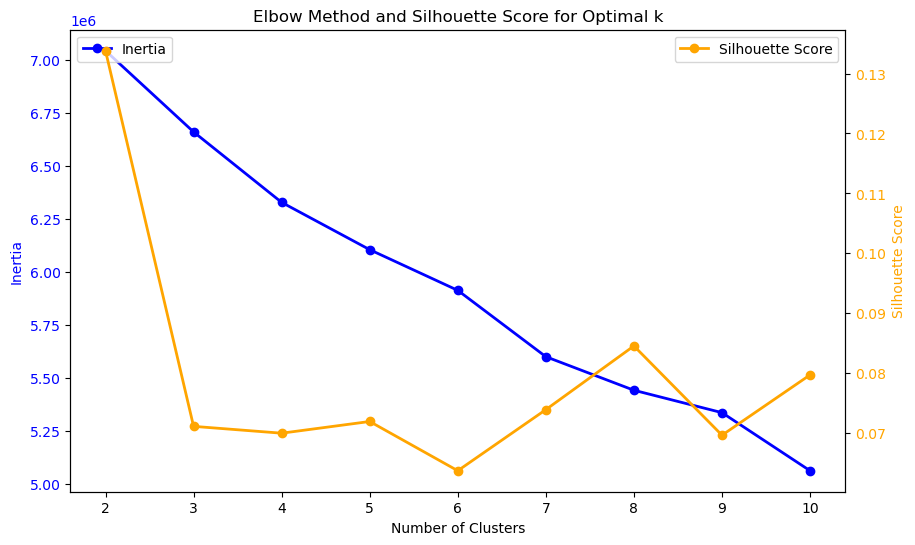

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

range_n_clusters = range(2, 11)

inertia = []
silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_smote_scaled)
    
    inertia.append(kmeans.inertia_)
    
    silhouette_avg = silhouette_score(X_smote_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

# Plotting both metrics on the same plot
plt.figure(figsize=(10, 6))

# Create a twin axis
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot inertia
ax1.plot(range_n_clusters, inertia, marker='o', color='blue', label='Inertia', linewidth=2)
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot silhouette scores
ax2.plot(range_n_clusters, silhouette_scores, marker='o', color='orange', label='Silhouette Score', linewidth=2)
ax2.set_ylabel('Silhouette Score', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and legends
plt.title('Elbow Method and Silhouette Score for Optimal k')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

### Compare cluster mean of K-means and GMM

In [12]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Fit K-means
kmeans_n_clusters = 3  
kmeans = KMeans(n_clusters=kmeans_n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_smote_scaled)

df_kmeans = pd.DataFrame(X_smote_scaled, columns=X_smote.columns)
df_kmeans['KMeans_Cluster'] = kmeans_labels
kmeans_means = df_kmeans.groupby('KMeans_Cluster').mean().reset_index()

# Fit GMM
gmm_n_clusters = 3  
gmm = GaussianMixture(n_components=gmm_n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(X_smote_scaled)

df_gmm = pd.DataFrame(X_smote_scaled, columns=X_smote.columns)
df_gmm['GMM_Cluster'] = gmm_labels
gmm_means = df_gmm.groupby('GMM_Cluster').mean().reset_index()


In [13]:
kmeans_means.T

,0,1,2
KMeans_Cluster,0.000000,1.000000,2.000000
HighBP,0.428019,0.598662,-1.021330
HighChol,0.330160,0.325151,-0.621051
CholCheck,0.097305,0.145819,-0.244050
BMI,0.419055,0.049380,-0.344831
Smoker,0.216722,0.055496,-0.214900
Stroke,0.457942,-0.080751,-0.212407
HeartDiseaseorAttack,0.513109,0.024523,-0.378359
PhysActivity,-0.599070,0.123703,0.255816
Fruits,-0.147111,0.052695,0.035580


In [15]:
gmm_means.T

,0,1,2
GMM_Cluster,0.000000,1.000000,2.000000
HighBP,0.482366,-0.011006,-0.243009
HighChol,0.387496,-0.009497,-0.192181
CholCheck,0.066284,0.166559,-0.811215
BMI,0.119335,-0.009941,-0.026714
Smoker,0.227859,-0.043259,0.061347
Stroke,2.318081,-0.250996,-0.250997
HeartDiseaseorAttack,1.050219,-0.048051,-0.417603
PhysActivity,-0.263068,0.036968,-0.010777
Fruits,-0.056399,0.025086,-0.081726


### Feature Engineering

In [28]:
# Calculate correlation between the new scores and the target variable
df_f=pd.DataFrame()
df_f['Diabetes_binary']=df_clean['Diabetes_binary']

df_f['HighBP'] = 2.8*df_clean['HighBP']
df_f['HighChol'] = 1.1*df_clean['HighChol']
df_f['GenHlth'] = .7*df_clean['GenHlth']
df_f['HeartDiseaseorAttack'] =.5*df_clean['HeartDiseaseorAttack']
df_f['CholCheck'] = .4*df_clean['CholCheck']
df_f['HvyAlcoholConsump'] = .3*df_clean['HvyAlcoholConsump']
df_f['Veggies'] =.4*df_clean['Veggies']


df_f['Smoker'] = .6*df_clean['Smoker']
df_f['Fruits'] = 5.5*df_clean['Fruits']
df_f['Sex'] = 0.7*df_clean['Sex']
df_f['PhysActivity'] = .4*df_clean['PhysActivity']
df_f['DiffWalk'] = .4*df_clean['DiffWalk']

df_f['Socio']=260*df_clean['Education']+120*df_clean['Income']+220*df_clean['Age']
df_f['Bio']=120*df_clean['BMI']+140*df_clean['Stroke']
df_f['Hlth']=1.1*df_clean['AnyHealthcare']+0.88*df_clean['MentHlth']+0.66*df_clean['PhysHlth']+ 1.2*df_clean['NoDocbcCost']

# Correlation with target
X = df_f.drop(columns=['Diabetes_binary'])
y = df_f['Diabetes_binary']

Accuracy: 0.9145178996974321


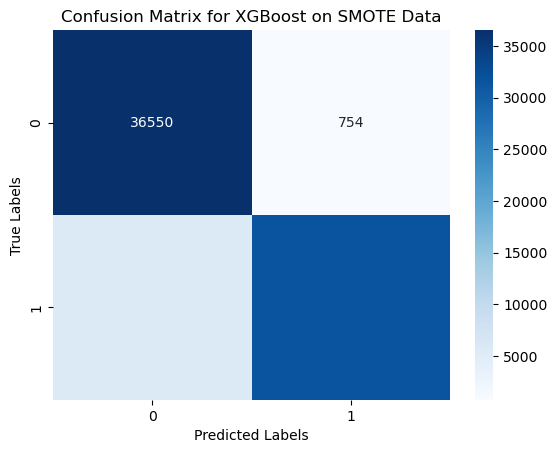

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92     37304
           1       0.98      0.85      0.91     37390

    accuracy                           0.91     74694
   macro avg       0.92      0.91      0.91     74694
weighted avg       0.92      0.91      0.91     74694



,Feature,Importance Score
0,HighBP,0.379336
1,HighChol,0.139286
2,GenHlth,0.096829
3,PhysActivity,0.074497
4,Sex,0.063154
5,Smoker,0.060707
6,HeartDiseaseorAttack,0.039483
7,Veggies,0.039304
8,DiffWalk,0.037886
9,HvyAlcoholConsump,0.031532


In [29]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
scaler = StandardScaler()
X_smote_scaled = scaler.fit_transform(X_smote)

X_train, X_test, y_train, y_test = train_test_split(X_smote_scaled, y_smote, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(eval_metric='logloss', alpha=1)
xgb_model.fit(X_train, y_train)


y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix for XGBoost on SMOTE Data")
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

importance_scores = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_smote.columns, 
    'Importance Score': importance_scores
})

feature_importance_df = feature_importance_df.sort_values(by='Importance Score', ascending=False).reset_index(drop=True)
feature_importance_df

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Convert data to PyTorch tensors
X = torch.tensor(X_smote_scaled, dtype=torch.float32)
y = torch.tensor(y_smote.values, dtype=torch.float32)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Feedforward Neural Network model
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),  # Input to hidden layer
            nn.ReLU(),
            nn.Dropout(0.3),  # Regularization
            nn.Linear(128, 64),  # Hidden layer
            nn.ReLU(),
            nn.Linear(64, 1),  # Output layer
            nn.Sigmoid()  # Sigmoid activation for binary classification
        )

    def forward(self, x):
        return self.network(x)

# Initialize the model
input_dim = X.shape[1]
model = SimpleNN(input_dim)

# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training parameters
epochs = 50
batch_size = 32

# Training loop
for epoch in range(epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
        # Prepare batch data
        X_batch = X_train[i:i + batch_size]
        y_batch = y_train[i:i + batch_size]
        
        # Forward pass
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate on validation data
    model.eval()
    with torch.no_grad():
        y_pred = (model(X_val).squeeze() > 0.5).float()
        val_accuracy = accuracy_score(y_val.numpy(), y_pred.numpy())
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy:.4f}")

# Final Evaluation
model.eval()
with torch.no_grad():
    y_pred_final = (model(X_val).squeeze() > 0.5).float()
    print("Classification Report:")
    print(classification_report(y_val.numpy(), y_pred_final.numpy()))


Epoch 1/50, Loss: 0.3212, Val Accuracy: 0.8571
Epoch 2/50, Loss: 0.1793, Val Accuracy: 0.8665
Epoch 3/50, Loss: 0.2106, Val Accuracy: 0.8687
Epoch 4/50, Loss: 0.1675, Val Accuracy: 0.8731
Epoch 5/50, Loss: 0.1629, Val Accuracy: 0.8741
Epoch 6/50, Loss: 0.1373, Val Accuracy: 0.8746
Epoch 7/50, Loss: 0.1263, Val Accuracy: 0.8764
Epoch 8/50, Loss: 0.1374, Val Accuracy: 0.8759
Epoch 9/50, Loss: 0.2245, Val Accuracy: 0.8790
Epoch 10/50, Loss: 0.1585, Val Accuracy: 0.8793
Epoch 11/50, Loss: 0.2695, Val Accuracy: 0.8785
Epoch 12/50, Loss: 0.3066, Val Accuracy: 0.8789
Epoch 13/50, Loss: 0.1489, Val Accuracy: 0.8793
Epoch 14/50, Loss: 0.1618, Val Accuracy: 0.8828
Epoch 15/50, Loss: 0.1341, Val Accuracy: 0.8799
Epoch 16/50, Loss: 0.1622, Val Accuracy: 0.8822
Epoch 17/50, Loss: 0.1556, Val Accuracy: 0.8791
Epoch 18/50, Loss: 0.1342, Val Accuracy: 0.8848
Epoch 19/50, Loss: 0.1177, Val Accuracy: 0.8834
Epoch 20/50, Loss: 0.1282, Val Accuracy: 0.8837
Epoch 21/50, Loss: 0.1406, Val Accuracy: 0.8827
E

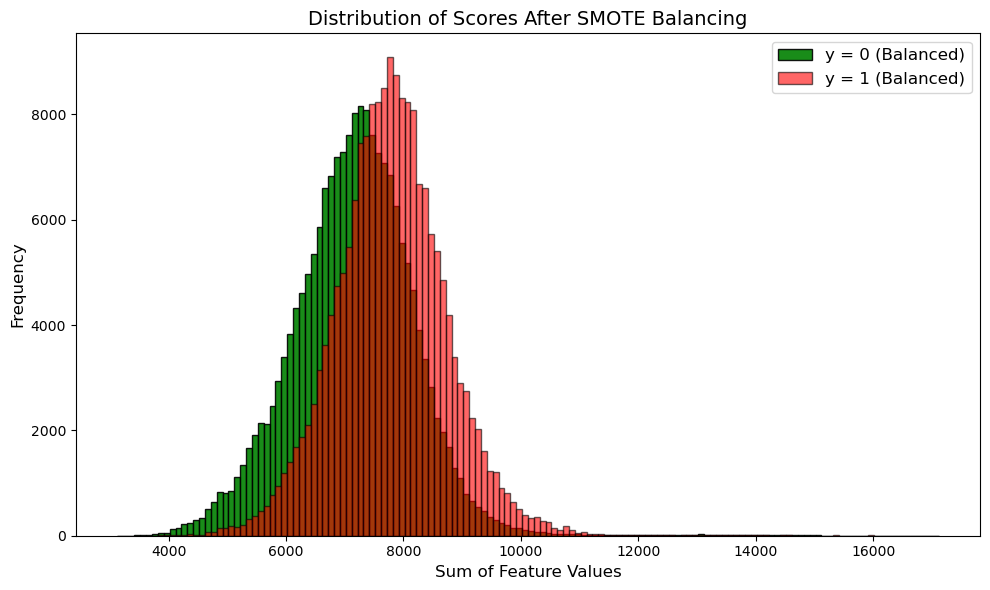

In [44]:
row_sums_smote = X_smote.sum(axis=1)

# Group row sums by the target variable y_smote
row_sums_0_smote = row_sums_smote[y_smote == 0]
row_sums_1_smote = row_sums_smote[y_smote == 1]

# Define common bins for both groups
bin_width = 100  # Set the bin width
bin_edges = np.arange(min(row_sums_smote), max(row_sums_smote) + bin_width, bin_width)

# Plot histograms for each group with aligned bins
plt.figure(figsize=(10, 6))
plt.hist(row_sums_0_smote, bins=bin_edges, alpha=0.9, label='y = 0 (Balanced)', color='green', edgecolor='black')
plt.hist(row_sums_1_smote, bins=bin_edges, alpha=0.6, label='y = 1 (Balanced)', color='red', edgecolor='black')

# Add labels, legend, and title
plt.title('Distribution of Scores After SMOTE Balancing', fontsize=14)
plt.xlabel('Sum of Feature Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()  

plt.show()

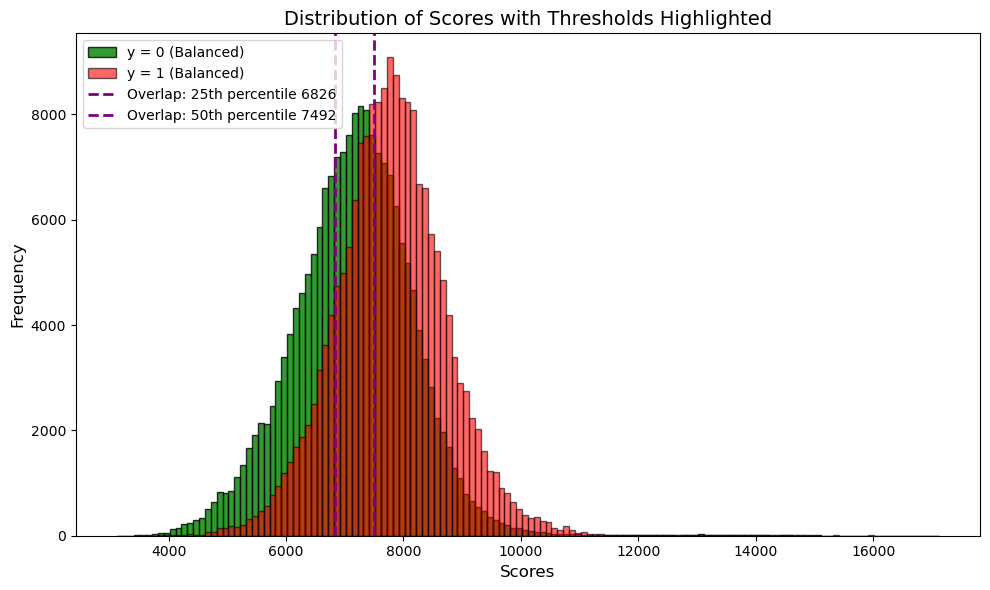

In [70]:
# Find the overlapping range
overlap_min = max(row_sums_0_smote.min(), row_sums_1_smote.min())
overlap_max = min(row_sums_0_smote.max(), row_sums_1_smote.max())

# Filter row sums within the overlapping range
overlap_data = row_sums_smote[(row_sums_smote >= overlap_min) & (row_sums_smote <= overlap_max)]

# Calculate 5th and 95th percentiles of the overlapping area
percentile_25_overlap = np.percentile(overlap_data, 25)
percentile_50_overlap = np.percentile(overlap_data, 50)

# Plot histograms for each group with aligned bins
plt.figure(figsize=(10, 6))
plt.hist(row_sums_0_smote, bins=bin_edges, alpha=0.8, label='y = 0 (Balanced)', color='green', edgecolor='black')
plt.hist(row_sums_1_smote, bins=bin_edges, alpha=0.6, label='y = 1 (Balanced)', color='red', edgecolor='black')

# Add vertical lines for the 90% overlap boundaries
plt.axvline(percentile_25_overlap, color='purple', linestyle='--', linewidth=2, label=f'Overlap: 25th percentile {percentile_25_overlap:.0f}')
plt.axvline(percentile_50_overlap, color='purple', linestyle='--', linewidth=2, label=f'Overlap: 50th percentile {percentile_50_overlap:.0f}')

# Add labels, legend, and title
plt.title('Distribution of Scores with Thresholds Highlighted', fontsize=14)
plt.xlabel('Scores', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.tight_layout()  # Adjust layout for better fit

plt.show()